# Showcase — Hurricane Ian from geostationary orbit (GOES, AWS Open Data)

Geostationary weather satellites watch the same hemisphere continuously, so they are how forecasters track hurricanes minute to minute. NOAA's **GOES-16** ABI imager publishes its imagery openly on AWS. This notebook uses the earthlens **amazon-s3** backend (unsigned, no credentials) to pull the **clean-infrared window (band 13)** over Hurricane **Ian** (September 2022) — the band that shows deep convective cloud tops day or night — and pyramids reprojects the geostationary grid to lat/lon on the fly.

> Public AWS Open Data — no credentials needed. The backend selects the first frame of the requested day.

## What this notebook does

1. **Fetch** the GOES-16 ABI band-13 (10.3 µm IR) scene over the Gulf/Florida.
2. **Convert** the scaled radiance to brightness temperature (K).
3. **Map** the cold cloud tops — Ian's deep convection stands out against the warm, clear background.

Colder (lower) brightness temperatures mark taller, more intense storm clouds.

In [1]:
import os, tempfile
import numpy as np, matplotlib.pyplot as plt
from loguru import logger
from earthlens import EarthLens
from pyramids.dataset import Dataset

logger.disable("earthlens"); logger.disable("pyramids")

# GOES-16 ABI L2 Cloud & Moisture Imagery, band C13 (clean IR window). The
# amazon-s3 backend reads it unsigned and pyramids reprojects geostationary -> WGS84.
path = None
try:
    paths = EarthLens(
        data_source="amazon-s3", dataset="goes", variables=["C13"],
        start="2022-09-29", end="2022-09-29",
        aoi=[-85.0, 24.0, -79.0, 31.0],   # Ian over Florida (W, S, E, N)
        path=tempfile.mkdtemp(),
    ).download(progress_bar=False)
    path = str(paths[0]) if paths else None
    print("granule:", os.path.basename(path) if path else None)
except Exception as exc:  # noqa: BLE001
    print("GOES download skipped:", exc)

granule: C13_2022272.tif


## The clean-IR window over Hurricane Ian

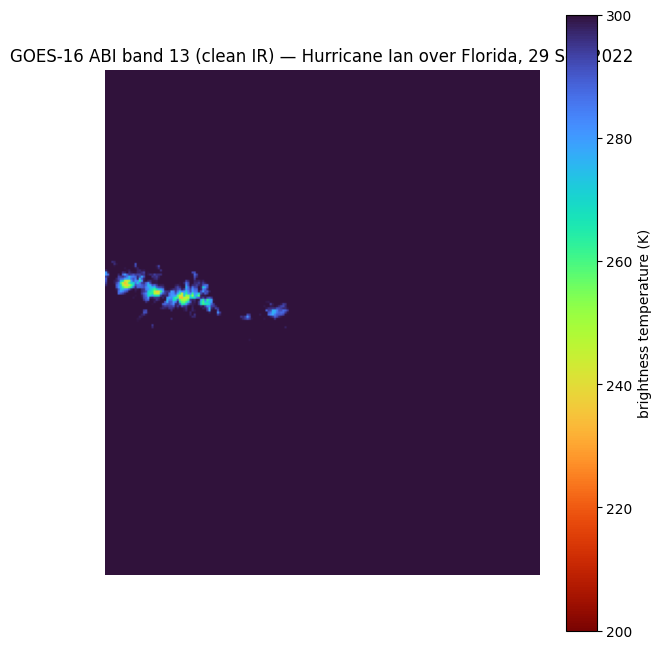

coldest cloud-top brightness temperature in scene: 233 K (-40 °C) — the deepest convection


In [2]:
# Read the reprojected raster, convert the scaled value to brightness temperature.
if path:
    ds = Dataset.read_file(path)
    arr = np.asarray(ds.read_array(), dtype="float32")
    bt = (arr[0] if arr.ndim == 3 else arr)
    bt = np.where(bt < 1, np.nan, bt) * 0.1          # scaled -> kelvin
    fig, ax = plt.subplots(figsize=(7, 8))
    im = ax.imshow(bt, cmap="turbo_r", vmin=200, vmax=300)
    ax.set_title("GOES-16 ABI band 13 (clean IR) — Hurricane Ian over Florida, 29 Sep 2022")
    ax.axis("off")
    fig.colorbar(im, ax=ax, label="brightness temperature (K)")
    plt.show()
    print(f"coldest cloud-top brightness temperature in scene: {np.nanmin(bt):.0f} K "
          f"({np.nanmin(bt)-273.15:.0f} °C) — the deepest convection")
else:
    print("no scene — rerun with network access")

## Recap

The earthlens **amazon-s3** backend pulls GOES ABI imagery from public AWS Open Data with no credentials, and pyramids reprojects the geostationary grid to lat/lon — turning a raw satellite granule into an analysis-ready brightness-temperature map of the hurricane's clouds.

## Try it yourself

- Switch `bucket="noaa-goes18"` for the Pacific, or band `C02` (visible) for a daytime view.
- Re-point the date/AOI at another storm or a wildfire-smoke pall.
- See the [Amazon S3 backend reference](../../reference/s3/introduction.md).